## Etape 1 : Importation des données

### 1.1 Packages

In [72]:
using Pkg

cd(@__DIR__)
Pkg.activate("../")
using Dates, SonifSismo
using WAV
using CairoMakie
using DSP
using Statistics

  Activating project at `c:\Users\ameli\Desktop\Stage\sonifSismo.jl`


### 1.2 Musique

In [ ]:
musique, sr_musique = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Danza Kuduro.wav") #Mettre le lien de sa musique
signal = musique[1:700000] #On coupe la musique pour faire beaucoup moins de données
println(sr_musique) #Fréquence d'échantillonage

44100.0


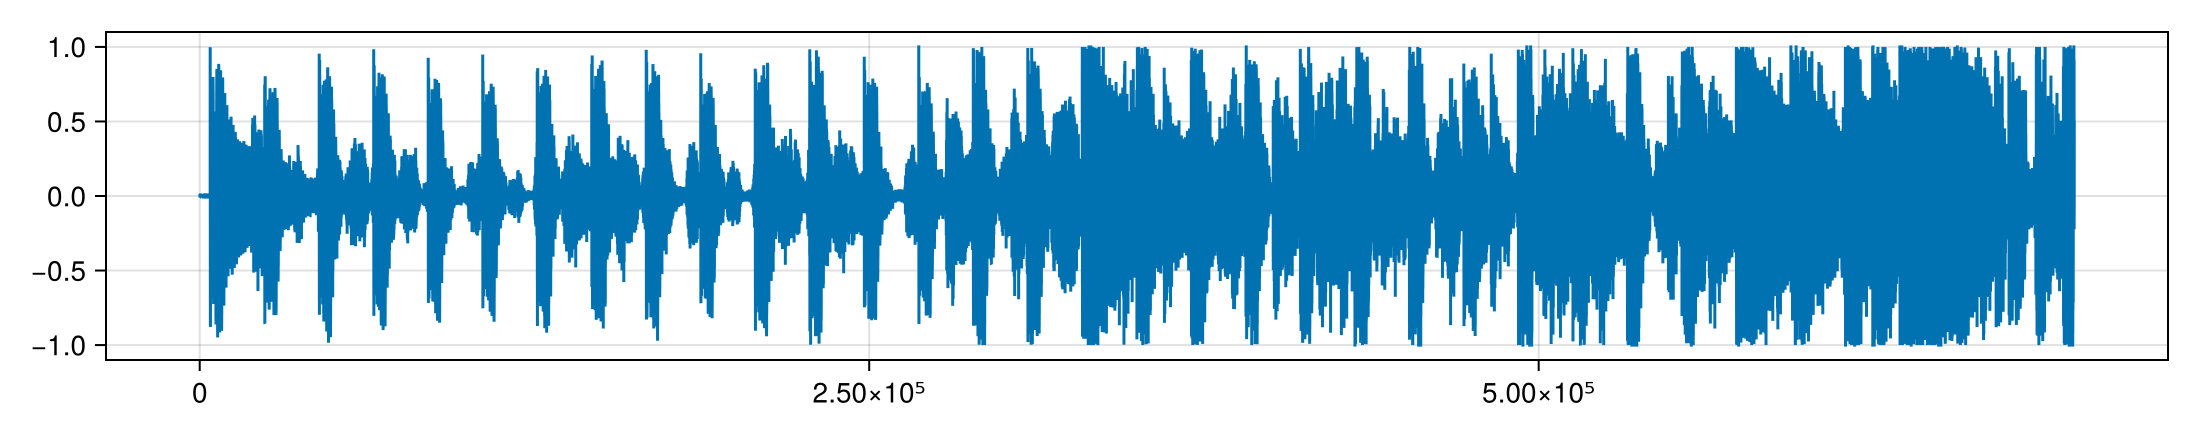

In [ ]:
#Plot de la musique

fig=Figure(size=(1100, 220))
ax=Axis(fig[1,1])
lines!(signal)
fig

### 1.3 Données sismiques

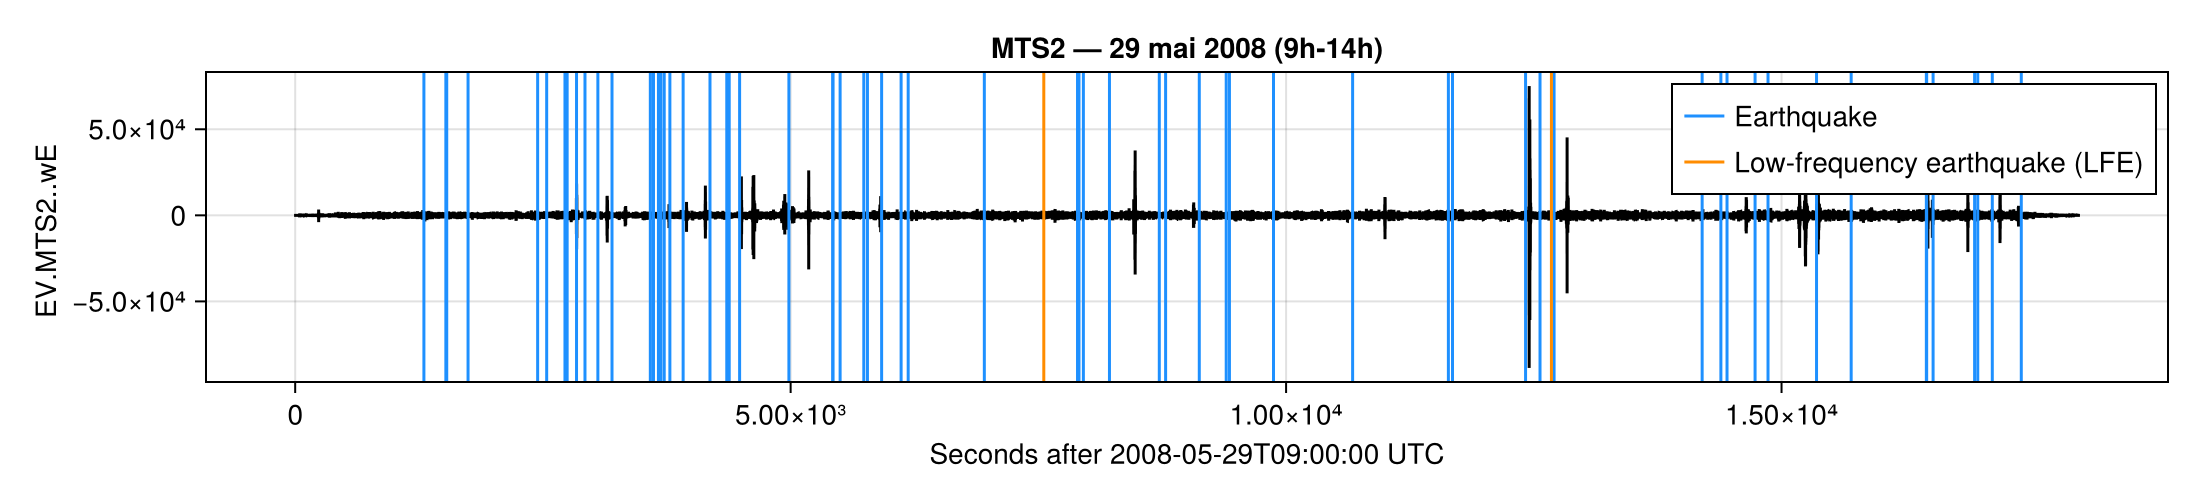

In [79]:
archive = DataArchive("C:/Users/ameli/Desktop/Stage/mtFujiContinuous")

t0_utc = DateTime(2008, 5, 29, 9, 0, 0) 
t1_utc = DateTime(2008, 5, 29, 14, 0, 0) 

events = read_catalog(archive; start=t0_utc, stop=t1_utc)


traces = read_window(
    archive,  t0_utc, t1_utc;
    stations  = "MTS2",
    channels  = ["wE"],
    processed = true,
    bandpass  = (0.1, 15),
)

plot_events = read_catalog(archive; start=t0_utc, stop=t1_utc)

wavefig = plot_waveforms(
    traces; events=plot_events,title="MTS2 — 29 mai 2008 (9h-14h)"
)

wavefig



## Etape 2 : Sonify_trace

Car les rendus sont beaucoup trop horrible, on va essayer de d'abord diminuer le son du séisme. 

In [76]:
include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

trace_wE = only(t for t in traces if strip(t.sta.cha) == "wE")

sonify = sonify_trace(
    trace_wE;
    acceleration=120,
    #octave=1,
    #harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=0.02
)

(signal = [-2.209453738224258e-12, -2.4165441624124983e-12, -2.62671725516454e-12, -2.8399730164803828e-12, -3.0563294184848168e-12, -3.275824133870828e-12, -3.4984291673851865e-12, -3.724144519027894e-12, -3.953031757537891e-12, -4.1850820033550705e-12  …  -2.17040357252237e-12, -2.179536609200292e-12, -2.1874318658019236e-12, -2.1940773286279697e-12, -2.1995562977727026e-12, -2.2038687732326277e-12, -2.2069431553081772e-12, -2.2088757943869327e-12, -2.2097126553589597e-12, -2.209453738224258e-12], sample_rate = 44100, playback_factor = 120.0, seismic_duration = 18000.01, audio_duration = 150.00009070294786)

## Etape 3 : Convolution

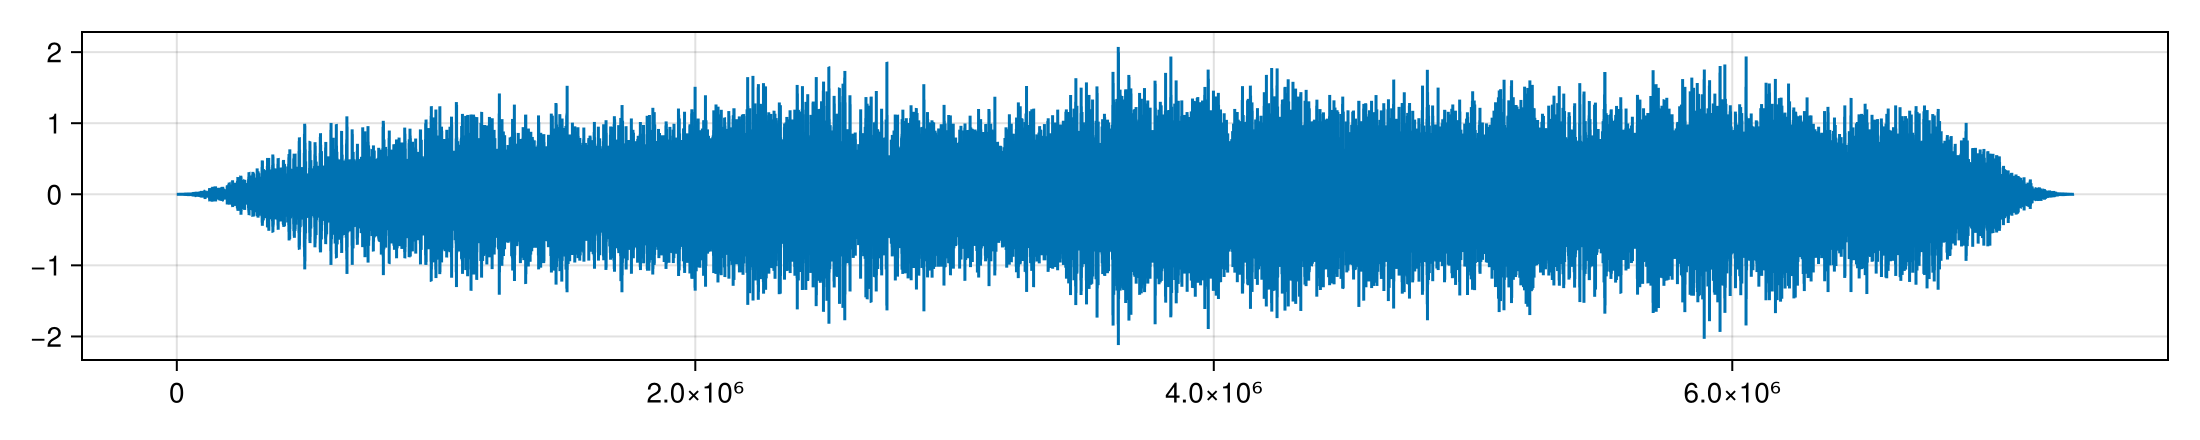

In [ ]:
convolution = conv(sonify[1], signal) #Convolution

fig_conv=Figure(size=(1100, 220))
ax=Axis(fig_conv[1,1])
lines!(convolution)
fig_conv

## Etape 4 : Enregistrement des fichiers


In [80]:
const AUDIO_OUTPUT = joinpath("C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\10Juin\\test6")
mkpath(AUDIO_OUTPUT)

save(joinpath(AUDIO_OUTPUT, "01_musique.png"), fig)
save(joinpath(AUDIO_OUTPUT, "02_séisme.png"), wavefig)
save(joinpath(AUDIO_OUTPUT, "03_conv.png"), fig_conv)

wavwrite(Float32.(convolution), joinpath(AUDIO_OUTPUT, "04_musique.wav"), Fs=sr_musique)
wavwrite(Float32.(conv(traces[1].t, signal)), joinpath(AUDIO_OUTPUT, "05_sans_sonify.wav"), Fs=sr_musique)
